# HW10

# 10.1

Confidence: 10

In [4]:
import os
from dotenv import load_dotenv
from pymongo import MongoClient
from urllib.parse import quote_plus
import matplotlib.pyplot as plt

load_dotenv()

# Use the specific variable names
USERNAME = os.getenv("MONGODB_USERNAME")
PASSWORD = os.getenv("MONGODB_PASSWORD")

#print(USERNAME)
#print(PASSWORD)

In [ ]:
uri = (
    "mongodb+srv://"
    f"{quote_plus(USERNAME)}:{quote_plus(PASSWORD)}"
    "@cluster0.wxor8.mongodb.net/"
    "?appName=Cluster0"
)

#print(uri)
client = MongoClient(uri)

In [6]:
client.admin.command("ping")
db = client["sample_mflix"]
movies = db["movies"]

In [7]:
total = movies.count_documents({})

pipeline = [
    {"$project": {"fields": {"$objectToArray": "$$ROOT"}}},
    {"$unwind": "$fields"},
    {"$group": {
        "_id": "$fields.k",
        "count": {"$sum": 1}
    }},
    {"$project": {
        "field": "$_id",
        "pct": {"$multiply": [{"$divide": ["$count", total]}, 100]}
    }},
    {"$sort": {"pct": -1}}
]

results = list(movies.aggregate(pipeline))

In [8]:
for r in results:
    print(f"{r['field']:30s} {r['pct']:6.2f}%")

title                          100.00%
_id                            100.00%
imdb                           100.00%
awards                         100.00%
lastupdated                    100.00%
year                           100.00%
type                           100.00%
num_mflix_comments             100.00%
countries                       99.95%
genres                          99.48%
languages                       98.92%
directors                       98.87%
cast                            98.30%
runtime                         97.94%
released                        97.79%
writers                         94.88%
plot                            94.63%
fullplot                        92.99%
tomatoes                        87.07%
poster                          84.52%
rated                           53.66%
metacritic                      32.62%


# 10.2

Confidence: 6

In [9]:
total = movies.count_documents({})

lacking = movies.count_documents({"tomatoes.critic": {"$exists": False}})

pct_lacking = (lacking / total) * 100
print(f"Documents lacking tomatoes.critic: {lacking:,} / {total:,} ({pct_lacking:.2f}%)")

Documents lacking tomatoes.critic: 10,808 / 21,349 (50.63%)


In [10]:
pipeline = [
    {"$group": {
        "_id": None,
        "total_wins": {"$sum": "$awards.wins"}
    }}
]

result = list(movies.aggregate(pipeline))
print(f"Total awards won: {result[0]['total_wins']:,}")

Total awards won: 86,742


# 10.3

Confidence: 7

- movies uses referencing (normalized model) — related data like comments are stored in a separate comments collection and linked by movie_id. Documents are smaller and leaner.

- embedded_movies uses embedding (denormalized model) — related data (such as comments) is embedded directly inside the movie document itself. Documents are larger but self-contained.

# 10.4

Confidence: 7

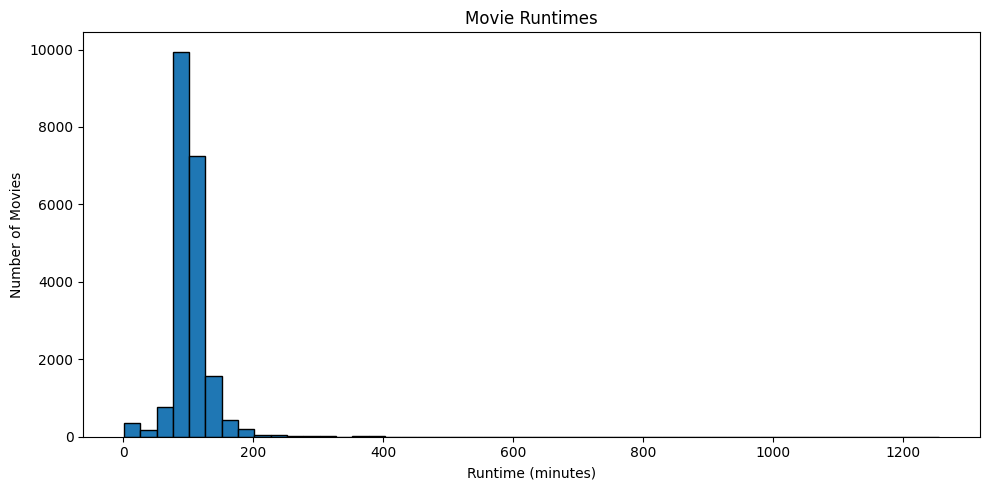

In [11]:
runtimes = [doc["runtime"] for doc in movies.find({"runtime": {"$exists": True}}, {"runtime": 1, "_id": 0})]

plt.figure(figsize=(10, 5))
plt.hist(runtimes, bins=50, edgecolor="black")
plt.title("Movie Runtimes")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

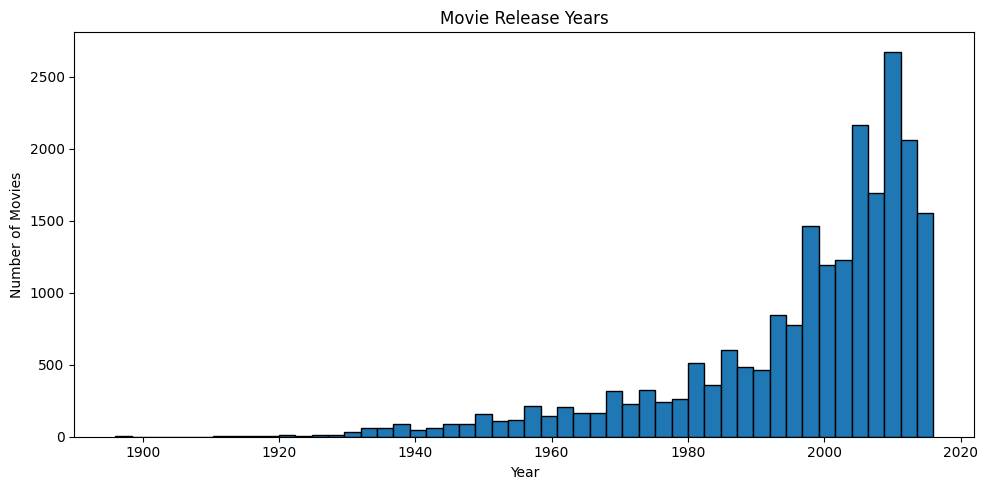

In [12]:
years = [doc["year"] for doc in movies.find({"year": {"$type": "int"}}, {"year": 1, "_id": 0})]

plt.figure(figsize=(10, 5))
plt.hist(years, bins=50, edgecolor="black")
plt.title("Movie Release Years")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

# 10.5

Confidence: 7

- An explicit schema enforces a fixed structure on all documents at write time (like SQL's CREATE TABLE), so every record must have the same fields and data types. 
- An implicit schema (as in MongoDB) imposes no structure at the database level. Documents in the same collection can have different fields, nested structures, and data types, with the application code responsible for interpreting the shape of the data.

# 10.6

Confidence: 7

Yes, this is a problem. While MongoDB's implicit schema allows flexibility, having team members freely choose their own field names and nesting structures creates an inconsistent collection where the same data is stored in multiple shapes — for example, one developer stores {"cast": [...]} while another stores {"actors": [...]}. This makes queries fragile and unpredictable: a query on cast will silently miss all documents that used actors, leading to incorrect results without any error. Application code becomes harder to maintain because it must defensively handle every possible shape rather than relying on a consistent structure.

Going forward, I would establish and enforce a written schema guidelines document that specifies the exact field names, data types, nesting structure, and which fields are required vs. optional for each document type. All new documents must conform to this agreed-upon structure, and any proposed changes to the schema must go through a team review before being implemented. This preserves the flexibility of the document model for legitimate evolution over time while preventing the chaos of uncoordinated, ad-hoc field naming.

# 10.7 Project 2

Confidence: 8

## Data Creation

### Item 1: Provenance

The raw data comes from the **Human ChatGPT Comparison Corpus (HC3)**, published by Hello-SimpleAI on HuggingFace (dataset ID: `Hello-SimpleAI/HC3`). The dataset was collected by the original authors by sourcing real-world questions from online platforms (Reddit ELI5, Wikipedia, medical and legal Q&A forums) and pairing each question with human-written answers from those platforms alongside answers generated by ChatGPT (`gpt-3.5-turbo`). The dataset contains approximately 24,000 question-answer pairs across seven domains: open Q&A, finance, medicine, law, psychology, Wikipedia, and computer science.

For this project, all domains are included to increase linguistic diversity and make the classifier more generalizable. Documents are fetched via the HuggingFace `datasets` Python library and ingested into MongoDB Atlas using the script described below.

### Item 2: Code Table

| File | Description | Link |
|---|---|---|
| `data/build_project2_data.py` | Fetches HC3 from HuggingFace, computes per-document features (word count, avg word length, sentence count, punctuation density), and bulk-inserts all documents into MongoDB Atlas with logging | [data/build_project2_data.py](../Project2/data/build_project2_data.py) |
| `pipeline/project2_pipeline.ipynb` | Queries MongoDB, engineers TF-IDF + statistical features, trains Logistic Regression, evaluates with ROC-AUC, and produces visualizations (confusion matrix, ROC curve, top-feature bar charts) | [pipeline/project2_pipeline.ipynb](../Project2/pipeline/project2_pipeline.ipynb) |

### Item 3: Bias Identification

- **Model version bias:** All ChatGPT responses in HC3 were generated by `gpt-3.5-turbo` circa 2022–2023. More recent models (GPT-4, Claude 3, Gemini) may produce stylistically different text, introducing distribution shift that the trained classifier may not handle.
- **Language bias:** HC3 is exclusively English. The classifier will not transfer to non-English academic contexts, and may also over-flag non-native English writers who adopt formal register patterns similar to AI output.
- **Domain representation bias:** HC3 over-represents structured domains (medicine, law) relative to unstructured essay writing. The model may underperform on freeform humanities essays.
- **Human answer quality bias:** Human answers in HC3 are sourced from forum posts, which vary widely in quality and formality. High-quality human answers may be misclassified as AI-generated if they are unusually formal.

### Item 4: Bias Mitigation

- **Model version bias** can be partially addressed by periodically retraining the classifier on newly collected AI-generated samples. The ingestion pipeline is parameterised to accept any dataset matching the HC3 schema.
- **Language bias** can be quantified by evaluating the classifier on a held-out subset tagged by writer language background (where available). False positive rates by demographic subgroup should be reported before institutional deployment.
- **Domain bias** can be mitigated by stratifying the train/test split by domain and reporting per-domain metrics, ensuring no single domain dominates evaluation results.
- **Human answer quality bias** can be partially addressed by the ROC curve: operating at a higher decision threshold (favoring precision over recall) reduces false positives at the cost of some true positive detections.

### Item 5: Rationale for Critical Decisions

- **All domains included (not just one):** Including all seven HC3 domains (medicine, law, finance, etc.) ensures the classifier must learn generalizable linguistic patterns rather than domain-specific vocabulary. A detector trained only on medical text might fail on legal text, but both share AI-vs-human stylistic signals.
- **One document per answer (not per question):** Each individual human answer and each ChatGPT answer is stored as a separate document. This maximizes the number of training examples and reflects the natural unit of classification (a single text block), not the question context.
- **Features computed at ingest time:** Statistical features (word count, avg word length, etc.) are computed in `build_project2_data.py` and stored in MongoDB alongside the raw text. This separates data preparation from modelling and allows the pipeline notebook to skip expensive recomputation during iteration.
- **No deduplication applied:** HC3 contains a small fraction of repeated question phrasings. We do not deduplicate because duplicates appear in both human and AI splits equally and do not constitute data leakage.

## Metadata

### Item 1: Implicit Schema Guidelines

Each document in the `project2.ai_text_detection` MongoDB collection follows this soft schema. Fields marked `required` must be present for the document to be valid for analysis. Optional fields may be absent for a small fraction of documents (e.g., if the original question string was empty in HC3).

```json
{
  "_id":                  "ObjectId",
  "text":                 "String — required, the full answer text",
  "label":                "human | ai — required, ground-truth class",
  "source":               "String — required, HC3 subset identifier",
  "question":             "String — optional, original question prompt",
  "word_count":           "Integer >= 1 — required",
  "avg_word_length":      "Float >= 0.0 — required",
  "sentence_count":       "Integer >= 1 — required",
  "punctuation_density":  "Float in [0, 1] — required",
  "ingested_at":          "ISODate (UTC) — required"
}
```

### Item 2: Data Table

| Table | Description | Link |
|---|---|---|
| `project2.ai_text_detection` | Primary MongoDB collection — one document per answer text, labeled human or AI, with computed stylometric features | stored in MongoDB Atlas |

### Item 3 & 4: Data Dictionary with Uncertainty Quantification

| Feature | Type | Description | Example | Uncertainty |
|---|---|---|---|---|
| `text` | String | Full text of the answer | "Insulin resistance is a condition in which..." | Low — direct copy from source; occasional encoding artifacts in special characters |
| `label` | String | Ground-truth authorship class | `"human"` or `"ai"` | Low for AI class (deterministically generated); moderate for human class (forum posts may contain AI-assisted writing post-2022) |
| `source` | String | HC3 domain subset identifier | `"HC3-all"` | None — programmatically assigned at ingest |
| `question` | String | Original question that prompted the answer | "What causes type 2 diabetes?" | Low — copied from source; may be empty for some HC3 rows |
| `word_count` | Integer | Number of whitespace-delimited tokens in `text` | `142` | ±1–2 tokens due to hyphenation and contraction handling edge cases |
| `avg_word_length` | Float | Mean character count per word after stripping punctuation | `4.7` | ±0.05 due to punctuation-stripping heuristic at word boundaries |
| `sentence_count` | Integer | Number of sentences determined by splitting on `.`, `!`, `?` | `8` | ±1–3 sentences for texts with abbreviations (e.g., "Dr. Smith said...") or bullet-point formatting |
| `punctuation_density` | Float ∈ [0,1] | Proportion of characters in `text` that are punctuation marks | `0.0312` | ±0.002 due to Unicode punctuation variants not covered by Python's `string.punctuation` |
| `ingested_at` | ISODate | UTC timestamp of MongoDB insertion | `2026-04-11T14:32:00Z` | None — system clock at ingest time |

# 10.8

Confidence: 8

Normalization in the relational model is the process of organizing data into separate tables to eliminate redundancy and ensure that each piece of information is stored in exactly one place. This is critical because when the same data is duplicated across multiple rows or tables, any update must be applied consistently everywhere — a failure to do so creates update anomalies, where different rows disagree on the same fact. Normalization also prevents insertion anomalies (being unable to record a fact without inserting unrelated data) and deletion anomalies (losing important information as a side effect of deleting a row). By enforcing that each attribute depends only on the primary key, the relational model guarantees data integrity and makes the schema easier to reason about, query, and maintain as the system grows.

# 10.9

Confidence: 8

Biases introduced at the data collection stage are particularly difficult to mitigate because they are baked into the ground truth itself — by the time the data reaches analysis, the distortion is indistinguishable from signal. If a dataset systematically under-represents a population (e.g., HC3 only contains English text, or only ChatGPT 3.5 responses), no amount of statistical correction at the modeling stage can recover information that was never collected. You cannot debias what you cannot observe. Furthermore, many collection biases are invisible at the time they are introduced: the researcher may not know which subgroups are missing, or the real-world distribution of the phenomenon may itself be unknown. Even when a bias is identified after the fact, mitigation strategies such as reweighting or oversampling can adjust the training distribution but cannot eliminate the fundamental gap between what was measured and what exists in the world.